In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import yfinance as yf
from datetime import time
sys.path.append(os.path.abspath("../src"))
from data_cleaner import DataCleanerConfig, DataCleaner, preprocess_data

# Para ir tocando data_cleaner sin tener que reiniciar el kernel
%load_ext autoreload
%autoreload 2

In [2]:
# Configuración para datos a 5m
cfg_5m = DataCleanerConfig(
    source="alpaca",
    symbol="QQQ",
    interval="5m",
    start_date="2022-01-01",
    end_date="2026-01-02",
   
)

cleaner = DataCleaner(cfg_5m)
df_raw = cleaner.cargar_datos()
df = preprocess_data(df_raw)

df

,symbol,datetime,open,high,low,close,volume,trade_count,vwap,volume_norm,...,log_ret_ch,log_ret_cl,log_ret_vwap,log_return_lag1,log_return_lag3,log_return_lag5,vol_rolling,rsi,macd,macd_signal
0,QQQ,2022-01-03 10:40:00+00:00,400.0700,400.08,400.03,400.0300,928.0,26.0,400.053334,-1.038042,...,-0.000125,0.000000,-0.000083,0.000275,0.000200,-0.000100,0.000261,77.599999,0.000423,0.000313
1,QQQ,2022-01-03 10:45:00+00:00,400.0200,400.07,400.00,400.0700,1083.0,38.0,400.032727,-0.923369,...,0.000000,0.000175,-0.000052,-0.000200,-0.000200,0.000300,0.000260,76.666666,0.000430,0.000336
2,QQQ,2022-01-03 10:50:00+00:00,400.0100,400.07,399.96,400.0500,4364.0,43.0,400.017493,-0.269167,...,-0.000050,0.000225,-0.000038,0.000100,0.000275,0.000200,0.000255,75.206611,0.000427,0.000354
3,QQQ,2022-01-03 10:55:00+00:00,400.0700,400.07,400.07,400.0700,208.0,5.0,400.070000,-0.973547,...,0.000000,0.000000,0.000131,-0.000050,-0.000200,-0.000200,0.000225,73.451327,0.000424,0.000368
4,QQQ,2022-01-03 11:00:00+00:00,400.1500,400.40,400.15,400.3500,5741.0,83.0,400.314086,0.077401,...,-0.000125,0.000500,0.000610,0.000050,0.000100,0.000275,0.000257,77.272726,0.000472,0.000389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189326,QQQ,2026-01-01 00:35:00+00:00,614.2984,614.32,614.24,614.2639,635.0,48.0,614.287381,-0.986389,...,-0.000091,0.000039,0.000025,0.000016,-0.000080,0.000016,0.000053,41.026336,-0.000044,-0.000070
189327,QQQ,2026-01-01 00:40:00+00:00,614.3000,614.30,614.30,614.3000,129.0,12.0,614.300000,-1.211694,...,0.000000,0.000000,0.000021,-0.000059,-0.000018,0.000065,0.000053,48.699270,-0.000040,-0.000064
189328,QQQ,2026-01-01 00:45:00+00:00,614.2800,614.32,614.28,614.3085,991.0,48.0,614.301639,-0.593634,...,-0.000019,0.000046,0.000003,0.000059,0.000016,-0.000080,0.000053,49.948952,-0.000036,-0.000058
189329,QQQ,2026-01-01 00:50:00+00:00,614.2903,614.30,614.23,614.2400,4718.0,128.0,614.258774,1.783280,...,-0.000098,0.000016,-0.000070,0.000014,-0.000059,-0.000018,0.000059,42.378047,-0.000040,-0.000055


In [3]:
df.columns

Index(['symbol', 'datetime', 'open', 'high', 'low', 'close', 'volume',
       'trade_count', 'vwap', 'volume_norm', 'trade_count_norm', 'return',
       'log_return_close', 'log_return_norm', 'log_ret_oc', 'log_ret_hl',
       'log_ret_ch', 'log_ret_cl', 'log_ret_vwap', 'log_return_lag1',
       'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd',
       'macd_signal'],
      dtype='object')

In [4]:
df = df.copy()
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

HORIZON = 24  # 24 velas de 5m = 2 horas

FEATURE_COLUMNS = [
    "volume_norm",
    "return",
    "log_return_close",
    "log_ret_oc",
    "log_ret_hl",
    "log_ret_ch",
    "log_ret_cl",
]

# trade_count: usa norm si existe, si no raw (y si no existe, no pasa nada)
if "trade_count_norm" in df.columns:
    FEATURE_COLUMNS.append("trade_count_norm")
elif "trade_count" in df.columns:
    FEATURE_COLUMNS.append("trade_count")

# 1-2 extras "seguros" (si existen)
for c in ["log_return_norm", "log_ret_vwap"]:
    if c in df.columns:
        FEATURE_COLUMNS.append(c)

# quitar las que no existan (por si Alpaca/YF no trae alguna)
FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if c in df.columns]

# TARGET
df["close_future"] = df["close"].shift(-HORIZON)
df = df.dropna(subset=["close_future"]).reset_index(drop=True)

df["direction_2h"] = (df["close_future"] > df["close"]).astype(np.int8)

# limpieza
df = df.drop(columns=["close_future"], errors="ignore")

print("N features:", len(FEATURE_COLUMNS))
print("FEATURE_COLUMNS:", FEATURE_COLUMNS)
print("Rows df:", len(df))


N features: 10
FEATURE_COLUMNS: ['volume_norm', 'return', 'log_return_close', 'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl', 'trade_count_norm', 'log_return_norm', 'log_ret_vwap']
Rows df: 189307


In [5]:
HORIZON = 24

# Trae datos del futuro a la fila actual con shift(-n)
df = df.copy()

df["close_future"] = df["close"].shift(-HORIZON)

# dirección:
df["direction_2h"] = (df["close_future"] > df["close"]).astype(np.int8)

df = df.dropna(subset=["direction_2h"]).reset_index(drop=True)
df = df.drop(columns=[c for c in ["target_2h", "close_future"] if c in df.columns])


In [6]:
df = df.copy()
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

VAL_START  = pd.Timestamp("2024-12-01", tz="UTC")
TEST_START = pd.Timestamp("2025-01-01", tz="UTC")
TEST_END   = pd.Timestamp("2026-01-01", tz="UTC")  # exclusivo

embargo = pd.Timedelta(hours=2)  # = horizonte (2h)

TRAIN_END = VAL_START - embargo
VAL_END   = TEST_START - embargo

df_train = df[df["datetime"] < TRAIN_END].copy()
df_val   = df[(df["datetime"] >= VAL_START) & (df["datetime"] < VAL_END)].copy()
df_test  = df[(df["datetime"] >= TEST_START) & (df["datetime"] < TEST_END)].copy()

print("train:", df_train["datetime"].min(), "->", df_train["datetime"].max(), "| rows:", len(df_train))
print("val:  ", df_val["datetime"].min(),   "->", df_val["datetime"].max(),   "| rows:", len(df_val))
print("test: ", df_test["datetime"].min(),  "->", df_test["datetime"].max(),  "| rows:", len(df_test))


train: 2022-01-03 10:40:00+00:00 -> 2024-11-29 21:55:00+00:00 | rows: 137650
val:   2024-12-02 09:00:00+00:00 -> 2024-12-31 21:55:00+00:00 | rows: 3912
test:  2025-01-01 00:10:00+00:00 -> 2025-12-31 22:55:00+00:00 | rows: 47724


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_raw = df_train[FEATURE_COLUMNS].values
X_val_raw   = df_val[FEATURE_COLUMNS].values
X_test_raw  = df_test[FEATURE_COLUMNS].values

X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled   = scaler.transform(X_val_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Reconstruimos dataframes escalados
df_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
df_train_scaled["datetime"] = df_train["datetime"].values
df_train_scaled["direction_2h"] = df_train["direction_2h"].values

df_val_scaled = pd.DataFrame(X_val_scaled, columns=FEATURE_COLUMNS)
df_val_scaled["datetime"] = df_val["datetime"].values
df_val_scaled["direction_2h"] = df_val["direction_2h"].values

df_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)
df_test_scaled["datetime"] = df_test["datetime"].values
df_test_scaled["direction_2h"] = df_test["direction_2h"].values




In [8]:
import torch
from torch.utils.data import Dataset, DataLoader

class SlidingWindowDataset(Dataset):
    def __init__(self, df, feature_cols, target_col="direction_2h", seq_len=128):
        """
        df: dataframe escalado con columnas features + datetime + target_2h
        """
        self.seq_len = seq_len
        self.feature_cols = feature_cols
        
        # Convertimos a tensores para PyTorch
        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.targets = torch.tensor(df[target_col].values, dtype=torch.float32)
        
        # Guardamos timestamps en formato string (por simplicidad)
        self.timestamps = pd.to_datetime(df["datetime"]).values.astype("datetime64[ns]")

    def __len__(self):
        return len(self.features) - self.seq_len + 1

    def __getitem__(self, idx):
        # Secuencia de tamaño seq_len
        x = self.features[idx : idx + self.seq_len]

        # Target para horizon = seq_len + 24 (pero ya está hecho en target_2h)
        y = self.targets[idx + self.seq_len -1]

        # Timestamp del momento donde hacemos la predicción
        ts = self.timestamps[idx + self.seq_len -1].astype("datetime64[ns]").astype(np.int64) 

        return x, y, ts


In [9]:
SEQ_LEN = 64  # ventana de observación (64 velas)

train_dataset = SlidingWindowDataset(
    df_train_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN
)

val_dataset = SlidingWindowDataset(
    df_val_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN
)

test_dataset = SlidingWindowDataset(
    df_test_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN
)

len(train_dataset), len(val_dataset), len(test_dataset)


(137587, 3849, 47661)

In [10]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)


In [11]:
# Ver un batch
xb, yb, tsb = next(iter(train_loader))

print("Batch X:", xb.shape)   # (batch, seq_len, num_features)
print("Batch y:", yb.shape)   # (batch,)
print("Timestamp example:", tsb[0])


Batch X: torch.Size([64, 64, 10])
Batch y: torch.Size([64])
Timestamp example: tensor(1709332800000000000)


# Ahora la LSTM

In [ ]:

class LockedDropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x):
        # x: (B, T, F)
        if (not self.training) or self.p == 0.0:
            return x
        # misma máscara para todos los timesteps
        mask = x.new_empty((x.size(0), 1, x.size(2))).bernoulli_(1 - self.p)
        mask = mask / (1 - self.p)
        return x * mask


In [ ]:
import torch.nn as nn

class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, vdrop_in=0.2):
        super().__init__()
        self.vdrop_in = LockedDropout(vdrop_in)

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=0.0,
            batch_first=True
        )

        self.norm = nn.LayerNorm(hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)  

    def forward(self, x):
        x = self.vdrop_in(x)
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        last = self.norm(last)
        y = self.fc(last).squeeze(-1)
        return y

In [27]:
input_dim = len(FEATURE_COLUMNS)

model = LSTMRegressor(
    input_dim=input_dim,
    hidden_dim=64,
    num_layers=2,
    dropout_lstm = 0.3,
    dropout_fc=0.3
)

model


LSTMRegressor(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.3)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

## Opcional
 
Gaussian dropout 

In [28]:
class GaussianDropout(nn.Module):
    def __init__(self, p):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training or self.p == 0.0:
            return x
        # std = sqrt(p / (1 - p))
        std = (self.p / (1.0 - self.p)) ** 0.5
        noise = torch.randn_like(x) * std + 1.0
        return x * noise


## Configuramos el entrenamiento

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

In [30]:
def train_lstm(model, train_loader, val_loader, num_epochs=30, patience=6, min_delta=1e-4, grad_clip=1.0):
    history = {"train_loss": [], "val_loss": []}
    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(1, num_epochs + 1):
        # ---- TRAIN ----
        model.train()
        train_losses = []

        for xb, yb, _ in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb).squeeze(-1)
            loss = criterion(logits, yb)

            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()
            train_losses.append(loss.item())

        # ---- VAL ----
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                logits = model(xb).squeeze(-1)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())

        epoch_train_loss = float(np.mean(train_losses))
        epoch_val_loss = float(np.mean(val_losses))

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)

        print(f"Epoch {epoch:02d} | Train loss: {epoch_train_loss:.6f} | Val loss: {epoch_val_loss:.6f}")

        # ---- EARLY STOPPING ----
        if epoch_val_loss < best_val - min_delta:
            best_val = epoch_val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping en epoch {epoch:02d} | best val: {best_val:.6f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


In [31]:
history = train_lstm(model, train_loader, val_loader, num_epochs=30, patience=6, min_delta=1e-4)
print("best val:", min(history["val_loss"]))


Epoch 01 | Train loss: 0.695072 | Val loss: 0.693156
Epoch 02 | Train loss: 0.691595 | Val loss: 0.694421
Epoch 03 | Train loss: 0.690725 | Val loss: 0.693316
Epoch 04 | Train loss: 0.689280 | Val loss: 0.693340
Epoch 05 | Train loss: 0.687043 | Val loss: 0.693236
Epoch 06 | Train loss: 0.684272 | Val loss: 0.688373
Epoch 07 | Train loss: 0.680362 | Val loss: 0.691043
Epoch 08 | Train loss: 0.674918 | Val loss: 0.692083
Epoch 09 | Train loss: 0.670372 | Val loss: 0.691110
Epoch 10 | Train loss: 0.665522 | Val loss: 0.686600
Epoch 11 | Train loss: 0.661358 | Val loss: 0.687473
Epoch 12 | Train loss: 0.655877 | Val loss: 0.685039
Epoch 13 | Train loss: 0.650362 | Val loss: 0.684736
Epoch 14 | Train loss: 0.644305 | Val loss: 0.696381
Epoch 15 | Train loss: 0.638214 | Val loss: 0.693829
Epoch 16 | Train loss: 0.631693 | Val loss: 0.699486
Epoch 17 | Train loss: 0.626230 | Val loss: 0.702109
Epoch 18 | Train loss: 0.618731 | Val loss: 0.725088
Epoch 19 | Train loss: 0.610921 | Val loss: 0.

In [32]:
import numpy as np

best_epoch = int(np.argmin(history["val_loss"]) + 1)
print("best epoch:", best_epoch)
print("best val:", float(min(history["val_loss"])))


best epoch: 13
best val: 0.6847358345985413


In [33]:
import numpy as np

p = float(df_val["direction_2h"].mean())
p = np.clip(p, 1e-9, 1-1e-9)
baseline = -(p*np.log(p) + (1-p)*np.log(1-p))

best_val = float(min(history["val_loss"]))

print("p(val):", p)
print("baseline:", float(baseline))
print("best val:", best_val)
print("improve:", float(baseline - best_val))


p(val): 0.5245398773006135
baseline: 0.6919422854021737
best val: 0.6847358345985413
improve: 0.007206450803632469


In [34]:
model.eval()
losses = []
with torch.no_grad():
    for xb, yb, _ in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb).squeeze(-1)
        losses.append(criterion(logits, yb).item())

test_loss = sum(losses) / len(losses)
print("TEST loss:", test_loss)


TEST loss: 0.7294353901939904


In [35]:
import numpy as np
import torch

# baseline en test (por frecuencia)
p_test = float(df_test["direction_2h"].mean())
p_test = float(np.clip(p_test, 1e-9, 1-1e-9))
baseline_test = -(p_test*np.log(p_test) + (1-p_test)*np.log(1-p_test))

model.eval()
losses, losses_flip = [], []
accs, accs_flip = [], []

with torch.no_grad():
    for xb, yb, _ in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb).squeeze(-1)

        # loss normal
        losses.append(criterion(logits, yb).item())

        # loss si el modelo va “al revés”
        losses_flip.append(criterion(-logits, yb).item())

        # accuracy normal
        prob = torch.sigmoid(logits)
        pred = (prob > 0.5).float()
        accs.append((pred == yb).float().mean().item())

        # accuracy flip
        prob_f = torch.sigmoid(-logits)
        pred_f = (prob_f > 0.5).float()
        accs_flip.append((pred_f == yb).float().mean().item())

test_loss = sum(losses)/len(losses)
test_loss_flip = sum(losses_flip)/len(losses_flip)

print("p(test):", p_test)
print("baseline_test:", baseline_test)
print("TEST loss:", test_loss)
print("TEST loss (flip):", test_loss_flip)
print("acc:", sum(accs)/len(accs))
print("acc (flip):", sum(accs_flip)/len(accs_flip))


p(test): 0.5341337691727432
baseline_test: 0.6908151387933461
TEST loss: 0.7294353901939904
TEST loss (flip): 0.7286821607775336
acc: 0.509611297543817
acc (flip): 0.4903887024661839


In [36]:
import numpy as np
import pandas as pd
import torch

UP_T = 0.55
DN_T = 0.45
FEE_BPS_PER_SIDE = 1.0
COST = 2.0 * (FEE_BPS_PER_SIDE / 10000.0)

TEST_START = "2025-01-01"
TEST_END   = "2026-01-01"  # exclusivo

def _ts_to_datetime(ts: np.ndarray) -> pd.DatetimeIndex:
    ts = ts.astype("int64")
    m = np.nanmax(ts)
    # autodetect por magnitud
    if m > 1e16:
        unit = "ns"
    elif m > 1e13:
        unit = "us"
    elif m > 1e10:
        unit = "ms"
    else:
        unit = "s"
    return pd.to_datetime(ts, unit=unit, utc=True, errors="coerce")

def predict_probs(model, loader, device):
    model.eval()
    logits_all, ts_all = [], []
    with torch.no_grad():
        for batch in loader:
            if len(batch) != 3:
                raise ValueError("Tu DataLoader debe devolver (X, y, timestamp).")
            xb, yb, ts = batch
            xb = xb.to(device)
            logits = model(xb).squeeze(-1).detach().cpu().numpy()
            logits_all.append(logits)
            ts_all.append(ts.detach().cpu().numpy())

    logits = np.concatenate(logits_all).astype(np.float64)
    ts = np.concatenate(ts_all).astype(np.int64)
    dt = _ts_to_datetime(ts)

    probs = 1.0 / (1.0 + np.exp(-logits))
    out = pd.DataFrame({"datetime": dt, "logit": logits, "prob_up": probs})
    out = out.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)
    return out

# 1) predicciones SOLO test
pred = predict_probs(model, test_loader, device)

start = pd.Timestamp(TEST_START, tz="UTC")
end   = pd.Timestamp(TEST_END, tz="UTC")
pred = pred[(pred["datetime"] >= start) & (pred["datetime"] < end)].copy()

# 2) returns futuros 2h en test
df_ret = df_test[["datetime", "close"]].copy()
df_ret["datetime"] = pd.to_datetime(df_ret["datetime"], utc=True, errors="coerce")
df_ret = df_ret.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)
df_ret = df_ret[(df_ret["datetime"] >= start) & (df_ret["datetime"] < end)].copy()

df_ret["close_future"] = df_ret["close"].shift(-HORIZON)
df_ret["fwd_logret_2h"] = np.log(df_ret["close_future"] / df_ret["close"])
df_ret = df_ret.dropna(subset=["fwd_logret_2h"]).drop(columns=["close_future"])

# 3) merge + señal
bt = pred.merge(df_ret, on="datetime", how="inner").sort_values("datetime").reset_index(drop=True)
bt["signal"] = np.where(bt["prob_up"] > UP_T, 1, np.where(bt["prob_up"] < DN_T, -1, 0)).astype(np.int8)

# 4) una operación cada HORIZON barras (sin solapar)
bt["i"] = np.arange(len(bt))
trades = bt[bt["i"] % HORIZON == 0].copy()

trades["strat_logret"] = trades["signal"] * trades["fwd_logret_2h"] - (trades["signal"].abs() * COST)
trades["equity"] = np.exp(trades["strat_logret"].cumsum())

total_return = (trades["equity"].iloc[-1] - 1.0) if len(trades) else 0.0

# Sharpe anualizado usando delta real entre trades (sin suposiciones)
if len(trades) >= 3 and trades["strat_logret"].std(ddof=0) > 0:
    mean = trades["strat_logret"].mean()
    std  = trades["strat_logret"].std(ddof=0)
    dt_med = trades["datetime"].diff().dropna().median()
    trades_per_year = (pd.Timedelta(days=365) / dt_med) if pd.notna(dt_med) else np.nan
    sharpe = (mean / std) * np.sqrt(trades_per_year) if pd.notna(trades_per_year) else np.nan
else:
    sharpe = np.nan

print("Backtest 2025")
print("Trades:", len(trades))
print(f"Total return: {total_return*100:.2f}%")
print(f"Sharpe (ann aprox): {sharpe:.2f}")

trades.head()


Backtest 2025
Trades: 1985
Total return: -38.76%
Sharpe (ann aprox): -3.80


,datetime,logit,prob_up,close,fwd_logret_2h,signal,i,strat_logret,equity
0,2025-01-02 13:30:00+00:00,-0.336692,0.416613,516.63,-0.008260,-1,0,0.008060,1.008093
24,2025-01-02 15:30:00+00:00,0.593501,0.644168,512.38,-0.007188,1,24,-0.007388,1.000672
48,2025-01-02 17:30:00+00:00,-0.978797,0.273130,508.71,-0.000629,-1,48,0.000429,1.001102
72,2025-01-02 19:30:00+00:00,-1.459499,0.188544,508.39,0.004416,-1,72,-0.004616,0.996491
96,2025-01-02 21:30:00+00:00,-1.215672,0.228699,510.64,-0.001646,-1,96,0.001446,0.997934


In [37]:
import numpy as np

executed = trades[trades["signal"] != 0].copy()

print("Executed trades:", len(executed), "de", len(trades))
if len(executed) > 0:
    winrate = (executed["strat_logret"] > 0).mean()
    total_ret = np.exp(executed["strat_logret"].sum()) - 1.0
    print("Winrate (executed):", f"{winrate:.2%}")
    print("Total return (executed):", f"{total_ret:.2%}")
else:
    print("No hay trades ejecutados con esos umbrales.")


Executed trades: 926 de 1985
Winrate (executed): 48.06%
Total return (executed): -38.76%


In [38]:
import pandas as pd

def show_range(name, dfx):
    d = pd.to_datetime(dfx["datetime"], utc=True)
    print(f"{name}: {d.min()} -> {d.max()} | rows: {len(dfx)}")

show_range("train", df_train)
show_range("val  ", df_val)
show_range("test ", df_test)


train: 2022-01-03 10:40:00+00:00 -> 2024-11-29 21:55:00+00:00 | rows: 137650
val  : 2024-12-02 09:00:00+00:00 -> 2024-12-31 21:55:00+00:00 | rows: 3912
test : 2025-01-01 00:10:00+00:00 -> 2025-12-31 22:55:00+00:00 | rows: 47724


# Solo un pequeño test para comprobar la parte out of sample

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- sanity ----
for v in ["trades", "df_test", "df_bt", "HORIZON"]:
    if v not in globals():
        raise ValueError(f"Falta `{v}` en memoria. Ejecuta antes la celda del backtest.")

# Rango OOS real (tu df_test)
test_start = pd.to_datetime(df_test["datetime"], utc=True).min()
test_end   = pd.to_datetime(df_test["datetime"], utc=True).max()

# Estimar tamaño de barra y embargo = HORIZON barras (por seguridad)
bar_delta = df_bt["datetime"].diff().dropna().median()
if pd.isna(bar_delta):
    bar_delta = pd.Timedelta(minutes=5)  # fallback típico
embargo = bar_delta * int(HORIZON)
strict_start = test_start + embargo

def summarize(executed_df, title):
    if len(executed_df) == 0:
        print(title, "-> NO HAY TRADES EJECUTADOS")
        return

    executed_df = executed_df.sort_values("datetime").copy()
    executed_df["equity_ex"] = np.exp(executed_df["strat_logret"].cumsum())

    # métricas
    n = len(executed_df)
    days = executed_df["datetime"].dt.floor("D").nunique()
    tpd = n / max(days, 1)

    winrate = (executed_df["strat_logret"] > 0).mean()
    avg = executed_df["strat_logret"].mean()
    std = executed_df["strat_logret"].std(ddof=0)
    sharpe = (avg / std) * np.sqrt(252 * tpd) if std > 0 else np.nan

    wins = executed_df.loc[executed_df["strat_logret"] > 0, "strat_logret"].sum()
    losses = -executed_df.loc[executed_df["strat_logret"] < 0, "strat_logret"].sum()
    pf = wins / losses if losses > 0 else np.inf

    eq = executed_df["equity_ex"].values
    peak = np.maximum.accumulate(eq)
    dd = (eq / peak) - 1.0
    max_dd = dd.min()

    total_ret = eq[-1] - 1.0

    print(title)
    print(f"Rango: {executed_df['datetime'].min()} -> {executed_df['datetime'].max()}")
    print(f"Executed trades: {n} | Days: {days} | Trades/day: {tpd:.2f}")
    print(f"Total return: {total_ret:.2%}")
    print(f"Winrate: {winrate:.2%} | PF: {pf:.2f} | Sharpe(ann): {sharpe:.2f} | MaxDD: {max_dd:.2%}")
    print(f"Longs: {(executed_df['signal']==1).sum()} | Shorts: {(executed_df['signal']==-1).sum()}")
    print()

    plt.figure(figsize=(12,4))
    plt.plot(executed_df["datetime"], executed_df["equity_ex"])
    plt.title(title + " (equity)")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True)
    plt.show()

# ---- 1) OOS test normal ----
tr_test = trades[(trades["datetime"] >= test_start) & (trades["datetime"] <= test_end)].copy()
ex_test = tr_test[tr_test["signal"] != 0].copy()
summarize(ex_test, "OOS TEST (df_test)")

# ---- 2) OOS test strict (ignorando primeras HORIZON barras del test) ----
tr_test_strict = trades[(trades["datetime"] >= strict_start) & (trades["datetime"] <= test_end)].copy()
ex_test_strict = tr_test_strict[tr_test_strict["signal"] != 0].copy()
summarize(ex_test_strict, f"OOS TEST STRICT (desde {strict_start})")


ValueError: Falta `df_bt` en memoria. Ejecuta antes la celda del backtest.

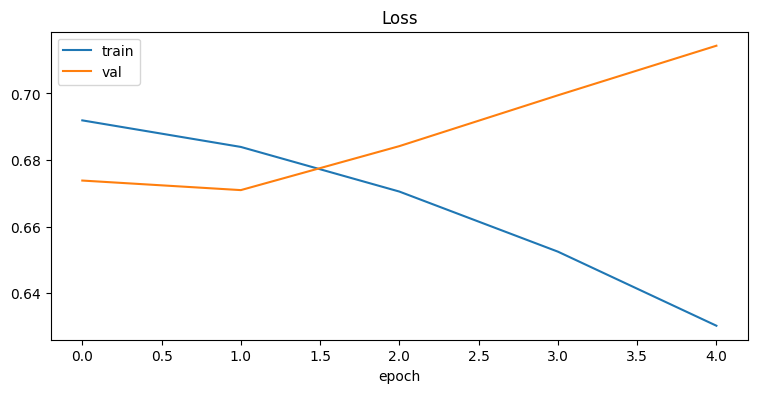

OBS OOS (df_test)
Executed trades: 91 | Days: 22 | Trades/day: 4.14
Total return: -4.93% | Sharpe(ann): -3.37

PERM TEST (null = señal aleatoria)
p-value Sharpe: 0.8414 | null 95%: 5.62
p-value Return: 0.8414 | null 95%: 8.62%


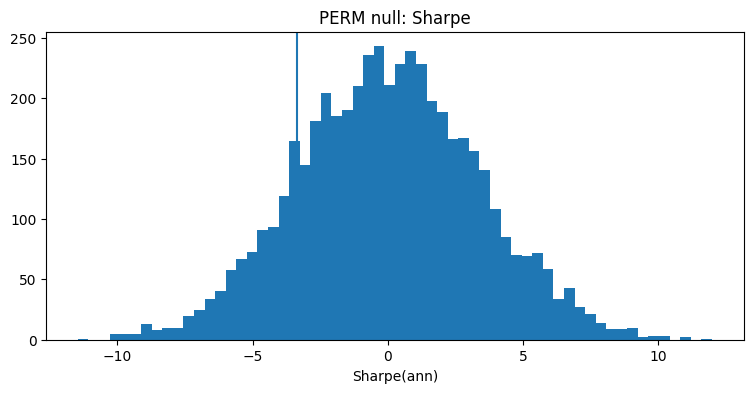

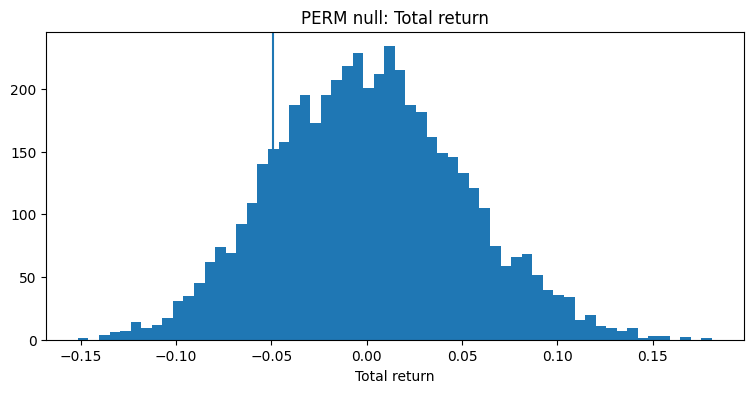


SHIFT TEST (null = misma señal pero desalineada)
p-value Sharpe: 0.8708 | null 95%: 4.67
p-value Return: 0.8708 | null 95%: 7.14%


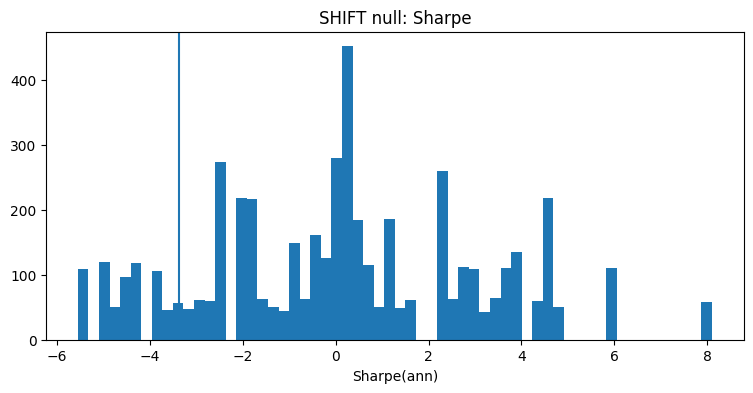

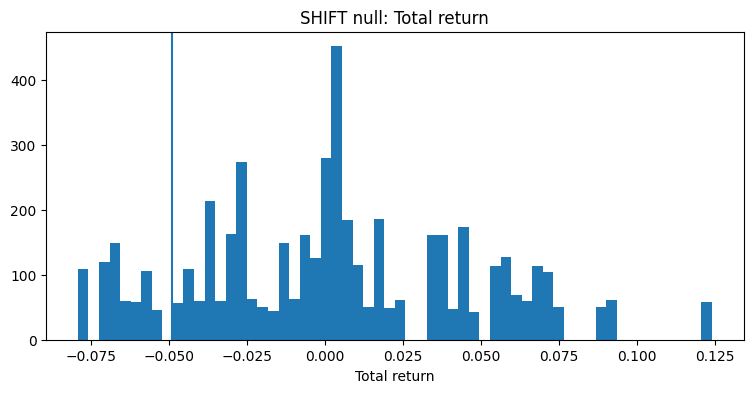

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) Gráfica simple de loss
# =========================
if "history" in globals() and isinstance(history, dict) and "train_loss" in history and "val_loss" in history:
    plt.figure(figsize=(9, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.title("Loss")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

# =========================
# 1) Construir trades OOS ejecutados (ex) en rango df_test
# =========================
if "trades" not in globals():
    raise ValueError("No existe `trades` en memoria. Ejecuta antes el backtest que lo crea.")
if "df_test" not in globals():
    raise ValueError("No existe `df_test` en memoria.")

test_start = pd.to_datetime(df_test["datetime"], utc=True).min()
test_end   = pd.to_datetime(df_test["datetime"], utc=True).max()

ex = trades[
    (trades["datetime"] >= test_start) &
    (trades["datetime"] <= test_end) &
    (trades["signal"] != 0)
].copy().sort_values("datetime").reset_index(drop=True)

if len(ex) < 20:
    raise ValueError(f"Demasiado pocos trades OOS ejecutados: {len(ex)}")

# =========================
# 2) Métrica observada
# =========================
obs = ex["strat_logret"].astype(float).values
days = ex["datetime"].dt.floor("D").nunique()
tpd = len(ex) / max(days, 1)

obs_avg, obs_std = obs.mean(), obs.std(ddof=0)
obs_sharpe = (obs_avg / obs_std) * np.sqrt(252 * tpd) if obs_std > 0 else np.nan
obs_ret = np.exp(obs.sum()) - 1.0

print("OBS OOS (df_test)")
print(f"Executed trades: {len(ex)} | Days: {days} | Trades/day: {tpd:.2f}")
print(f"Total return: {obs_ret:.2%} | Sharpe(ann): {obs_sharpe:.2f}")

# columnas necesarias para los null tests
for c in ["fwd_logret_2h", "cost", "signal"]:
    if c not in ex.columns:
        raise ValueError(f"Falta la columna `{c}` en `ex`.")

fwd  = ex["fwd_logret_2h"].astype(float).values
cost = ex["cost"].astype(float).values
sig  = ex["signal"].astype(float).values

# =========================
# 3) PERM TEST (señal aleatoria)
# =========================
N = 5000
rng = np.random.default_rng(42)

sharpes_perm = np.empty(N, dtype=float)
rets_perm    = np.empty(N, dtype=float)

for i in range(N):
    sig_perm = rng.permutation(sig)  # rompe alineación señal-return
    strat = sig_perm * fwd - cost
    avg, std = strat.mean(), strat.std(ddof=0)
    sharpes_perm[i] = (avg / std) * np.sqrt(252 * tpd) if std > 0 else -np.inf
    rets_perm[i]    = np.exp(strat.sum()) - 1.0

p_sh_perm = (np.sum(sharpes_perm >= obs_sharpe) + 1) / (N + 1)
p_rt_perm = (np.sum(rets_perm    >= obs_ret)    + 1) / (N + 1)

print("\nPERM TEST (null = señal aleatoria)")
print(f"p-value Sharpe: {p_sh_perm:.4f} | null 95%: {np.quantile(sharpes_perm, 0.95):.2f}")
print(f"p-value Return: {p_rt_perm:.4f} | null 95%: {np.quantile(rets_perm, 0.95):.2%}")

plt.figure(figsize=(9, 4))
plt.hist(sharpes_perm[np.isfinite(sharpes_perm)], bins=60)
plt.axvline(obs_sharpe)
plt.title("PERM null: Sharpe")
plt.xlabel("Sharpe(ann)")
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(rets_perm[np.isfinite(rets_perm)], bins=60)
plt.axvline(obs_ret)
plt.title("PERM null: Total return")
plt.xlabel("Total return")
plt.show()

# =========================
# 4) SHIFT TEST (circular shift: preserva estructura temporal de la señal)
# =========================
sharpes_shift = np.empty(N, dtype=float)
rets_shift    = np.empty(N, dtype=float)

for i in range(N):
    k = rng.integers(1, len(sig))  # shift no-cero
    sig_shift = np.roll(sig, k)
    strat = sig_shift * fwd - cost
    avg, std = strat.mean(), strat.std(ddof=0)
    sharpes_shift[i] = (avg / std) * np.sqrt(252 * tpd) if std > 0 else -np.inf
    rets_shift[i]    = np.exp(strat.sum()) - 1.0

p_sh_shift = (np.sum(sharpes_shift >= obs_sharpe) + 1) / (N + 1)
p_rt_shift = (np.sum(rets_shift    >= obs_ret)    + 1) / (N + 1)

print("\nSHIFT TEST (null = misma señal pero desalineada)")
print(f"p-value Sharpe: {p_sh_shift:.4f} | null 95%: {np.quantile(sharpes_shift, 0.95):.2f}")
print(f"p-value Return: {p_rt_shift:.4f} | null 95%: {np.quantile(rets_shift, 0.95):.2%}")

plt.figure(figsize=(9, 4))
plt.hist(sharpes_shift[np.isfinite(sharpes_shift)], bins=60)
plt.axvline(obs_sharpe)
plt.title("SHIFT null: Sharpe")
plt.xlabel("Sharpe(ann)")
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(rets_shift[np.isfinite(rets_shift)], bins=60)
plt.axvline(obs_ret)
plt.title("SHIFT null: Total return")
plt.xlabel("Total return")
plt.show()
